# Quantization error


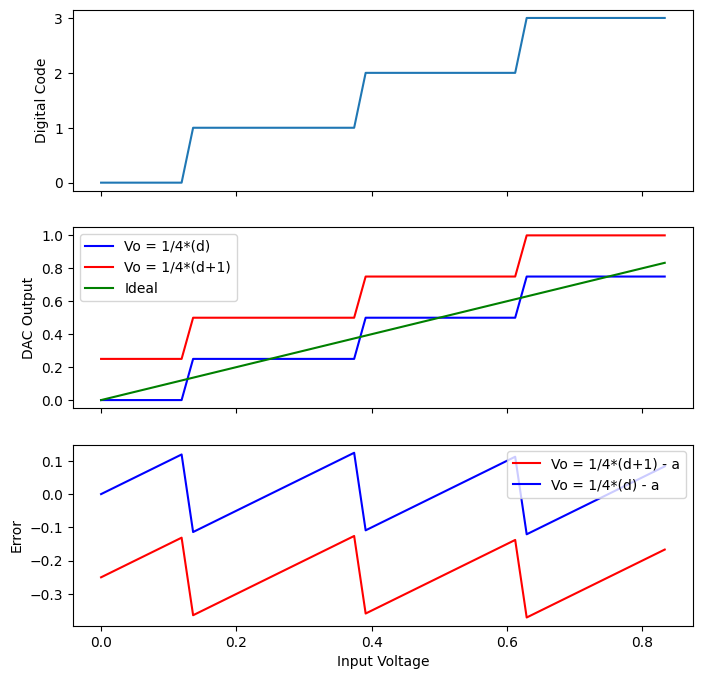

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

vref = 1
n = 2
lsb = vref/2**n 
a = np.linspace(0,vref - lsb*2/3,50) 

d = np.round(a/lsb)

vb = vref/4*(d) 
vd = vref/4*(d+1)

fig,ax = plt.subplots(3,1,figsize=(8,8),sharex=True)
ax[0].plot(a,d,label="Digital Code")
ax[0].set_ylabel("Digital Code")
ax[1].plot(a,vb,label="Vo = 1/4*(d)",color="blue")
ax[1].plot(a,vd,label="Vo = 1/4*(d+1)",color="red")
ax[1].set_ylabel("DAC Output")
ax[1].plot(a,a,label="Ideal",color="green")
ax[1].legend()
ax[2].plot(a,a-vd,label="Vo = 1/4*(d+1) - a",color="red")
ax[2].plot(a,a-vb,label="Vo = 1/4*(d) - a",color="blue")
ax[2].set_ylabel("Error")
ax[2].set_xlabel("Input Voltage")
plt.legend()
plt.savefig("../media/dac_error.pdf")
plt.savefig("../media/dac_error.svg")
plt.show()



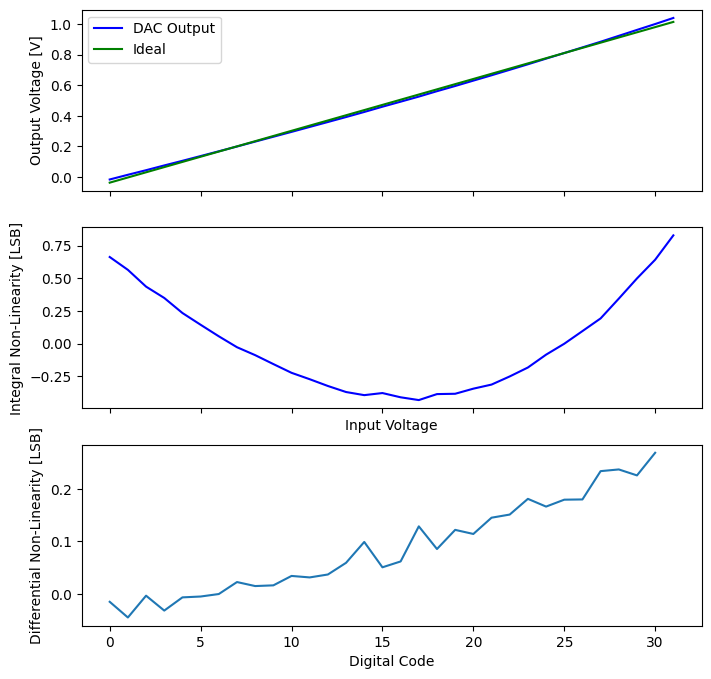

In [ ]:
from hashlib import sha1
import numpy as np
import matplotlib.pyplot as plt

vref = 1
n = 5
lsb = vref/2**n 
d = np.linspace(0,2**n-1,2**n)

#d^2 = d**2
dac_lsb = vref/2**n
vb = (dac_lsb- dac_lsb/32)*d - dac_lsb/2 + d**2*dac_lsb**2/16  + d**3*dac_lsb**3/16  + np.random.randn(2**n)*dac_lsb/100

p = np.polyfit(d,vb,1)
a = np.polyval(p,d)


inl = vb -a 
inl = inl/dac_lsb
dnl = np.diff(vb)/dac_lsb - 1

fig,ax = plt.subplots(3,1,figsize=(8,8),sharex=True)
ax[0].plot(d,vb,label="DAC Output",color="blue")
ax[0].set_ylabel("Output Voltage [V]")
ax[0].plot(d,a,label="Ideal",color="green")
ax[0].legend()
a#x[0].legend()
ax[1].plot(d,inl,label="Vo = 1/4*(d) - a",color="blue")
ax[1].set_ylabel("Integral Non-Linearity [LSB]")
ax[1].set_xlabel("Input Voltage")
ax[2].plot(d[:-1],dnl,label="Differential Non-Linearity")
ax[2].set_ylabel("Differential Non-Linearity [LSB]")
ax[2].set_xlabel("Digital Code")

#plt.legend()
plt.savefig("../media/dac_inl_dnl.pdf")
plt.savefig("../media/dac_inl_dnl.svg")
plt.show()